In [ ]:
import pandas as pd
import matplotlib.pyplot as plt # added to env
import seaborn as sns # added to env


print(f'pandas {pd.__version__}')
print(f'matplotlib {plt.matplotlib.__version__}')
print(f'seaborn {sns.__version__}')


pandas 2.0.3
matplotlib 3.7.5
seaborn 0.13.2


In [ ]:
df_bindingdb = pd.read_csv('data/bindingdb_processed.csv')
df_bindingnet = pd.read_csv('data/bindingnet_processed.csv')
df_pdbbind = pd.read_csv('data/pdbbind_processed.csv')

ba_bindingdb = 'pK'
ba_bindingnet = '-logAffi'
ba_pdbbind = '-logKd/Ki'

ligand_bindingdb = 'mol2_file' # problem: ids connected to targets, not unique ligands
ligand_bindingnet = 'compnd'
# ligand_pdbbind =  # cannot find ligand column

protein_bindingdb = 'pdb_file'
protein_bindingnet = 'pdb' # column named target as well, don't know what that is...
protein_pdbbind = 'PDB_code'

print(f"Number of binding affinities in BindingDB: {df_bindingdb[ba_bindingdb].count()}")
print(f"Number of binding affinities in BindingNet: {df_bindingnet[ba_bindingnet].count()}")
print(f"Number of binding affinities in PDBBind: {df_pdbbind[ba_pdbbind].count()}")

# binding affinities in BindingDB: 8822
# binding affinities in BindingNet: 69727
# binding affinities in PDBBind: 19308


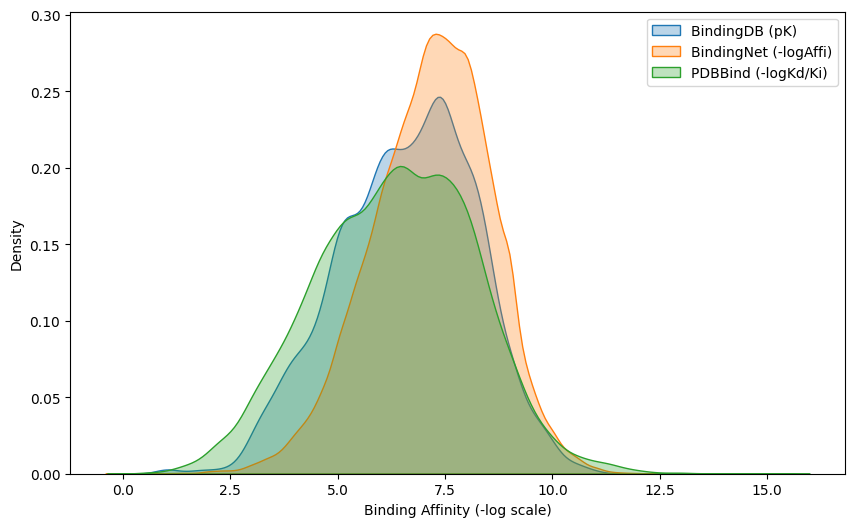

In [56]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_bindingdb[ba_bindingdb], label='BindingDB (pK)', fill=True, alpha=0.3)
sns.kdeplot(df_bindingnet[ba_bindingnet], label='BindingNet (-logAffi)', fill=True, alpha=0.3)
sns.kdeplot(df_pdbbind[ba_pdbbind], label='PDBBind (-logKd/Ki)', fill=True, alpha=0.3)
plt.xlabel('Binding Affinity (-log scale)')
plt.ylabel('Density')
plt.legend()
plt.show()

Number of unique proteins in BindingDB: 1311
Number of unique proteins in BindingNet: 5903
Protein with most ligands (BindingDB): 2V0Z.pdb (19 ligands)
Protein with most ligands (BindingNet): 4n6h (765 ligands)
Number of proteins with more than 60 ligands: 174 (2.9%)


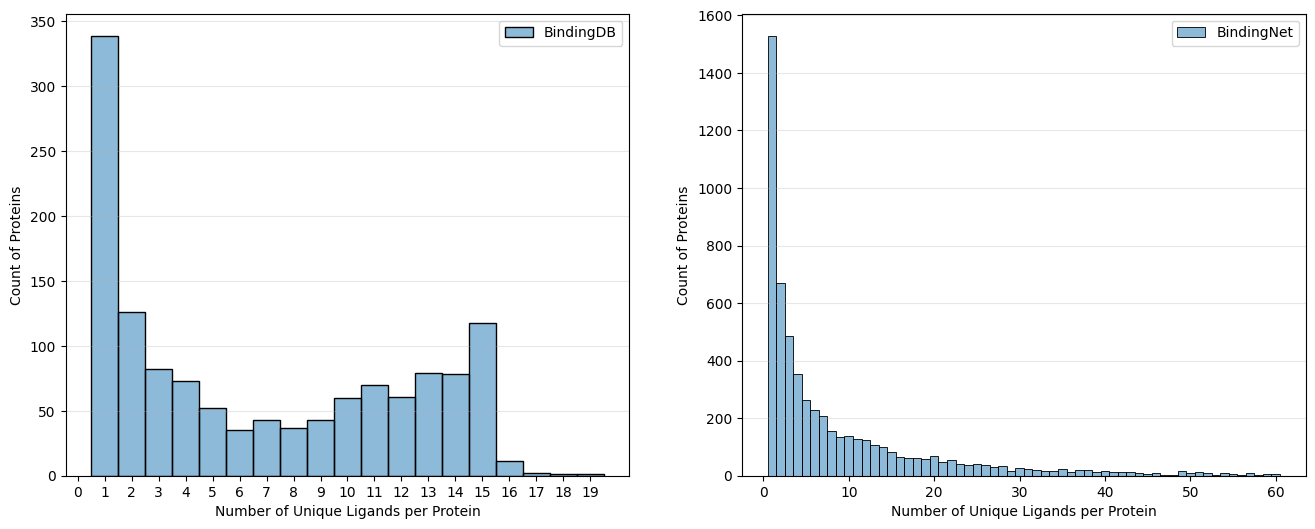

In [62]:
# unique proteins
print(f"Number of unique proteins in BindingDB: {df_bindingdb[protein_bindingdb].nunique()}")
print(f"Number of unique proteins in BindingNet: {df_bindingnet[protein_bindingnet].nunique()}")

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
ligands_per_protein = df_bindingdb.groupby(protein_bindingdb)[ligand_bindingdb].nunique()
most_ligands_protein = ligands_per_protein.idxmax()
most_ligands_count = ligands_per_protein.max()
print(f"Protein with most ligands (BindingDB): {most_ligands_protein} ({most_ligands_count} ligands)")

sns.histplot(ligands_per_protein, discrete=True, label='BindingDB', alpha=0.5)
plt.xticks(range(0, ligands_per_protein.max() + 1))
plt.xlabel('Number of Unique Ligands per Protein')
plt.ylabel('Count of Proteins')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
ligands_per_protein = df_bindingnet.groupby(protein_bindingnet)[ligand_bindingnet].nunique()
most_ligands_protein = ligands_per_protein.idxmax()
most_ligands_count = ligands_per_protein.max()
print(f"Protein with most ligands (BindingNet): {most_ligands_protein} ({most_ligands_count} ligands)")

# to avoid skewing
threshold = 60
num_skipped_proteins = (ligands_per_protein > threshold).sum()
print(f"Number of proteins with more than {threshold} ligands: {num_skipped_proteins} ({num_skipped_proteins / len(ligands_per_protein) * 100:.1f}%)")
ligands_per_protein = ligands_per_protein[ligands_per_protein <= threshold]

sns.histplot(ligands_per_protein, discrete=True, label='BindingNet', alpha=0.5)
plt.xlabel('Number of Unique Ligands per Protein')
plt.ylabel('Count of Proteins')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.show()

Number of unique ligands in BindingDB: 8821
Number of unique ligands in BindingNet: 65835
Ligand with most proteins (BindingNet): CHEMBL388978 (21 proteins)


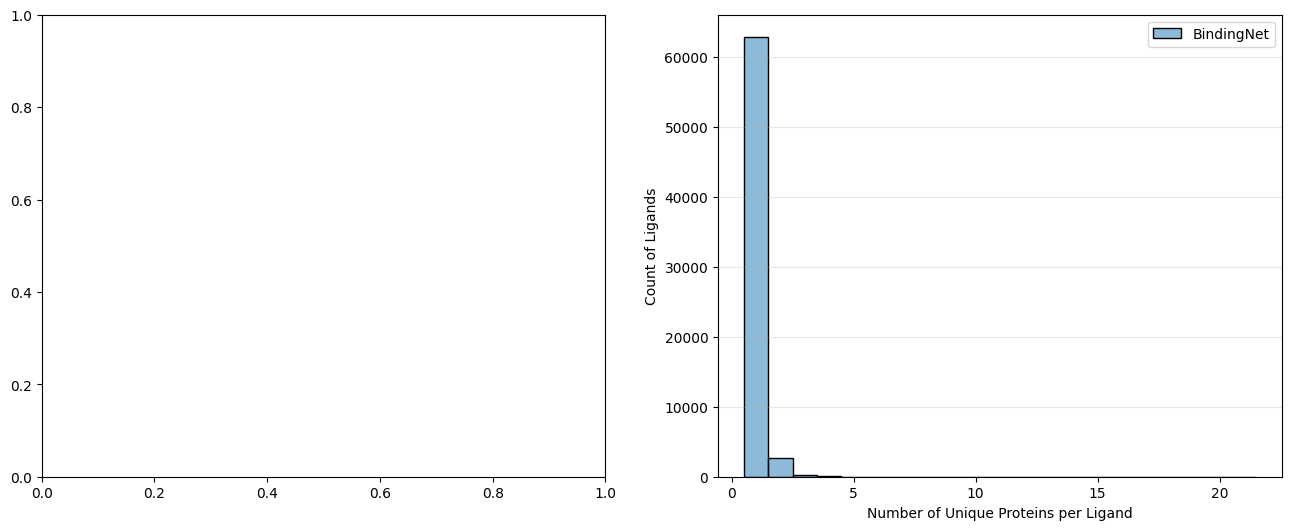

In [66]:
# unique ligands
print(f"Number of unique ligands in BindingDB: {df_bindingdb[ligand_bindingdb].nunique()}")
print(f"Number of unique ligands in BindingNet: {df_bindingnet[ligand_bindingnet].nunique()}")

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
# proteins_per_ligand = df_bindingdb.groupby(ligand_bindingdb)[protein_bindingdb].nunique()
# most_proteins_ligand = proteins_per_ligand.idxmax()
# most_proteins_count = proteins_per_ligand.max()
# print(f"Ligand with most proteins (BindingDB): {most_proteins_ligand} ({most_proteins_count} proteins)")

# sns.histplot(proteins_per_ligand, discrete=True, label='BindingDB', alpha=0.5)
# plt.xticks(range(0, proteins_per_ligand.max() + 1))
# plt.xlabel('Number of Unique Proteins per Ligand')
# plt.ylabel('Count of Ligands')
# plt.legend()
# plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
proteins_per_ligand = df_bindingnet.groupby(ligand_bindingnet)[protein_bindingnet].nunique()
most_proteins_ligand = proteins_per_ligand.idxmax()
most_proteins_count = proteins_per_ligand.max()
print(f"Ligand with most proteins (BindingNet): {most_proteins_ligand} ({most_proteins_count} proteins)")

sns.histplot(proteins_per_ligand, discrete=True, label='BindingNet', alpha=0.5)
plt.xlabel('Number of Unique Proteins per Ligand')
plt.ylabel('Count of Ligands')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.show()